In [276]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sc.settings.verbosity = 0             # verbosity: errors (0), warnings (1), info (2), hints (3)

from scipy.stats import zscore, pearsonr
from statsmodels.stats.multitest import fdrcorrection

In [277]:
%cd /home/orimosko/projects/phago/downloaded/

/home/orimosko/projects/phago/downloaded


In [278]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')  # low dpi (dots per inch) yields small inline figures

scanpy==1.9.8 anndata==0.9.2 umap==0.5.6 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.6 pynndescent==0.5.4


In [279]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

In [345]:
adata = sc.read_h5ad("/mc_disk2/data/h5ads/phago/melanoma_UM_filtered.h5ad")

In [347]:
# Keeps only the primary melanoma samples
adata = adata[adata.obs.Sample.str.len() < 7]

In [348]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell


/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:00)


In [349]:
sc.pp.highly_variable_genes(adata)

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [350]:
sc.pp.pca(adata, use_highly_variable=True)

computing PCA
    on highly variable genes
    with n_comps=50


    finished (0:00:01)


In [351]:
sc.external.pp.bbknn(adata, batch_key='Sample')

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)


In [352]:
sc.tl.umap(adata)

computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:21)


In [353]:
sc.tl.leiden(adata, resolution=0.5)

running Leiden clustering


    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:10)


In [356]:
sc.tl.rank_genes_groups(adata, groupby='leiden')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


In [358]:
annot_list = ['Melanoma cells', 'Melanoma cells',
              'Melanoma cells',
              'T cells',
              'Melanoma cells', 
              'Myeloid cells',
              'Melanoma cells',
              'Rentinal neural cells',
              'Retinal pigment epithelium']
adata.obs['annot'] = pd.Categorical([annot_list[int(i)] for i in adata.obs.leiden],
                                    categories=['Melanoma cells', 
                                                'Retinal pigment epithelium', 
                                                'Rentinal neural cells',
                                                'T cells', 
                                                'Myeloid cells'])

/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


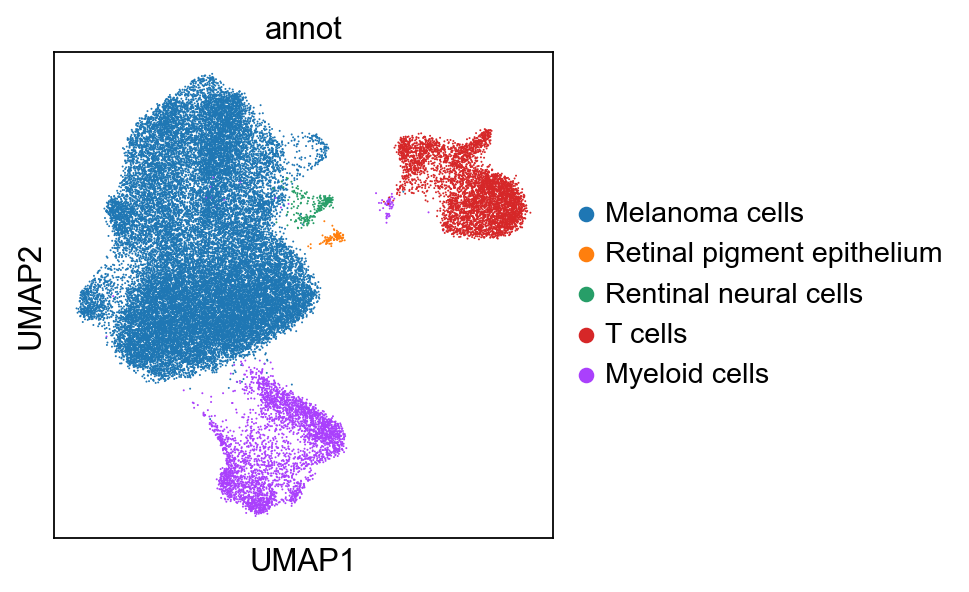

In [359]:
sc.pl.umap(adata, color='annot', save='_UM_new.pdf')

/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


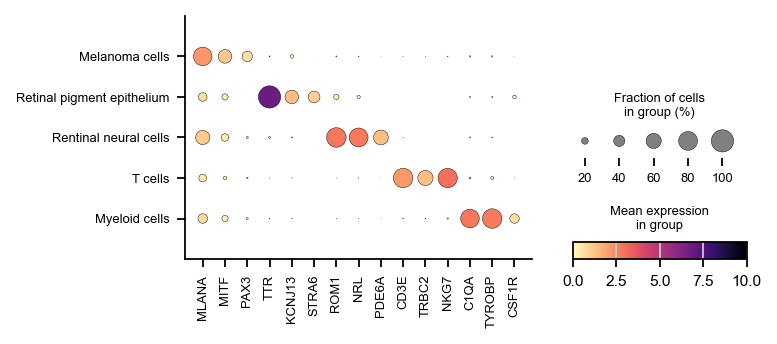

In [360]:
dot = sc.pl.dotplot(
    adata,
    ['MLANA', 'MITF', 'PAX3', 
     'TTR', 'KCNJ13', 'STRA6', 
     'ROM1', 'NRL', 'PDE6A',
     'CD3E', 'TRBC2', 'NKG7',
     'C1QA', 'TYROBP', 'CSF1R'], 
    groupby='annot',
    figsize=(4.5, 2),
    vmax=10,
    vmin=0,
    cmap="magma_r",
    return_fig=True 
)

fig = dot.get_axes()['mainplot_ax'].get_figure()

# Hide top and right spines for all axes
for ax in fig.axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Shrink main dots
for artist in dot.get_axes()['mainplot_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)

# Shrink legend dots
for artist in dot.get_axes()['size_legend_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)
    
for label in ax.get_xticklabels():
    label.set_fontsize(7)
for label in ax.get_yticklabels():
    label.set_fontsize(7)

fig.savefig('UM_figures/dotplothuman_UM_new.pdf')

In [361]:
macdata = adata[adata.obs.annot == "Myeloid cells"].copy()

In [365]:
sc.pp.highly_variable_genes(macdata)

extracting highly variable genes


    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [366]:
sc.pp.pca(macdata, use_highly_variable=True)

computing PCA
    on highly variable genes
    with n_comps=50


    finished (0:00:00)


In [367]:
sc.external.pp.bbknn(macdata, batch_key='Sample')

computing batch balanced neighbors


	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [369]:
sc.tl.leiden(macdata, resolution=0.5)

running Leiden clustering
    finished: found 4 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


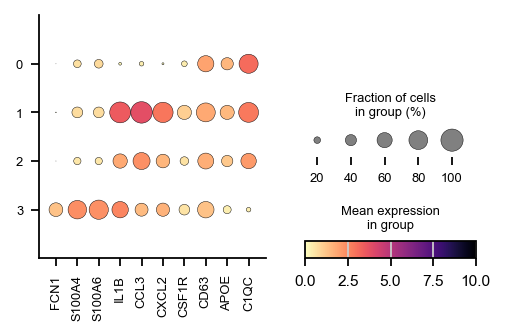

In [373]:
dot = sc.pl.dotplot(
    macdata,
    ['FCN1', 'S100A4', 'S100A6', 
     'IL1B', 'CCL3', 'CXCL2', 'CSF1R',
     'CD63', 'APOE', 'C1QC'],
    groupby='leiden',
    figsize=(3.5, 2),
    vmax=10,
    vmin=0,
    cmap="magma_r",
    return_fig=True 
)

fig = dot.get_axes()['mainplot_ax'].get_figure()

# Hide top and right spines for all axes
for ax in fig.axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Shrink main dots
for artist in dot.get_axes()['mainplot_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)

# Shrink legend dots
for artist in dot.get_axes()['size_legend_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)
    
for label in ax.get_xticklabels():
    label.set_fontsize(7)
for label in ax.get_yticklabels():
    label.set_fontsize(7)

plt.show()

In [374]:
macdata.obs.leiden.value_counts()

leiden
0    1673
1    1144
2     455
3     223
Name: count, dtype: int64

In [375]:
annot_list = ['Macrophages', 'MonMacs', 'MonMacs', 'Monocytes']
macdata.obs['annot'] = pd.Categorical([annot_list[int(i)] for i in macdata.obs.leiden],
                                    categories=['Monocytes', 'MonMacs', 'Macrophages'])

/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


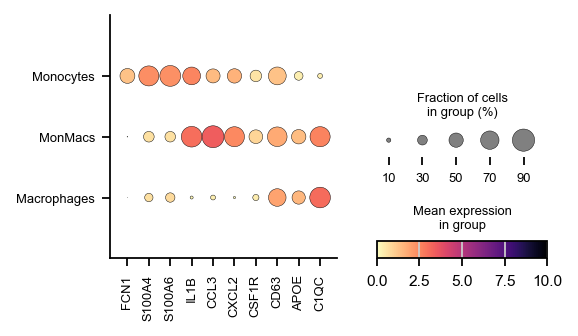

In [377]:
dot = sc.pl.dotplot(
    macdata,
    ['FCN1', 'S100A4', 'S100A6', 
     'IL1B', 'CCL3', 'CXCL2', 'CSF1R',
     'CD63', 'APOE', 'C1QC'],
    groupby='annot',
    figsize=(3.5, 2),
    vmax=10,
    vmin=0,
    cmap="magma_r",
    return_fig=True 
)

fig = dot.get_axes()['mainplot_ax'].get_figure()

# Hide top and right spines for all axes
for ax in fig.axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
# Shrink main dots
for artist in dot.get_axes()['mainplot_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)

# Shrink legend dots
for artist in dot.get_axes()['size_legend_ax'].collections:
    artist.set_sizes(artist.get_sizes() * 0.5)
    
for label in ax.get_xticklabels():
    label.set_fontsize(7)
for label in ax.get_yticklabels():
    label.set_fontsize(7)

fig.savefig('UM_figures/dotplothuman_UM_macrophages_new.pdf')

In [378]:
allmacdata = macdata.copy()

In [379]:
macdata = macdata[macdata.obs.leiden == "0"].copy()

In [381]:
macdata.shape

(1673, 33694)

In [384]:
new_up_and_corr_genes_human = [
    "FTH1", "WFDC17", "CCL9", "FABP5", "CSTB", "MARCO", "CTSK", "CD63", "LGALS3",
    "LYZ", "ESD", "FTL", "CD68", "RNH1", "GPNMB", "MT1A", "CAPG", "TUBA1C",
    "CRIP1", "ACP5", "LGALS1", "SOD2", "CALM1", "CALR", "TMSB10", "GAPDH", "NME1",
    "SLC39A2", "MRPL52", "EMP3", "CLEC4D", "ANXA4", "CTSB", "TYMS", "CTSZ", "ANPEP",
    "TCEAL9", "MSR1", "MANF", "CCL17", "CYBA", "ATP5ME", "GLRX", "CD24", "ATP6V1C1",
    "TSPO", "CALM3", "PRDX1", "ATP5MJ", "CTSC", "ANXA5", "MT2A", "BCAP31", "HINT1",
    "VAT1", "ENO1", "PYCARD", "ALDOA", "CAV1", "GLA", "FABP4", "NQO2", "ATP6V0B",
    "MFGE8", "TIMM13"
]

In [385]:
for g in new_up_and_corr_genes_human:
    print(g)

FTH1
WFDC17
CCL9
FABP5
CSTB
MARCO
CTSK
CD63
LGALS3
LYZ
ESD
FTL
CD68
RNH1
GPNMB
MT1A
CAPG
TUBA1C
CRIP1
ACP5
LGALS1
SOD2
CALM1
CALR
TMSB10
GAPDH
NME1
SLC39A2
MRPL52
EMP3
CLEC4D
ANXA4
CTSB
TYMS
CTSZ
ANPEP
TCEAL9
MSR1
MANF
CCL17
CYBA
ATP5ME
GLRX
CD24
ATP6V1C1
TSPO
CALM3
PRDX1
ATP5MJ
CTSC
ANXA5
MT2A
BCAP31
HINT1
VAT1
ENO1
PYCARD
ALDOA
CAV1
GLA
FABP4
NQO2
ATP6V0B
MFGE8
TIMM13


In [386]:
sc.tl.score_genes(macdata, gene_list=new_up_and_corr_genes_human, score_name="effero_score", use_raw=False)

computing score 'effero_score'
    finished: added
    'effero_score', score of gene set (adata.obs).
    499 total control genes are used. (0:00:00)


In [391]:
sc.pp.highly_variable_genes(macdata)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [392]:
sc.pp.pca(macdata, use_highly_variable=True)

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)


In [393]:
sc.external.pp.bbknn(macdata, batch_key='Sample')

computing batch balanced neighbors
	finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [394]:
sc.tl.umap(macdata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:02)


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

In [420]:
PHAGO_COLOR = "#FF97E2"
NONPHAGO_COLOR = "#00A86B"
PBS_COLOR = "#63A7FF"
RODOHIGH_COLOR = "#8A54A5"
GRAY = "#D3D3D3" 
custom_cmap = LinearSegmentedColormap.from_list('rodo_scale', ["#E0E8F0", PHAGO_COLOR, "#6A3A7F"])
r_cmap = LinearSegmentedColormap.from_list('r_scale', [NONPHAGO_COLOR, GRAY, PHAGO_COLOR, RODOHIGH_COLOR])

In [423]:
umap_coords = pd.DataFrame(macdata.obsm['X_umap'], index=macdata.obs_names, columns=['x', 'y'])

In [427]:
cell_order = macdata.obs.sort_values(by='effero_score').index

In [479]:
macdata.obs['logcounts'] = np.log1p(macdata.obs.total_counts)

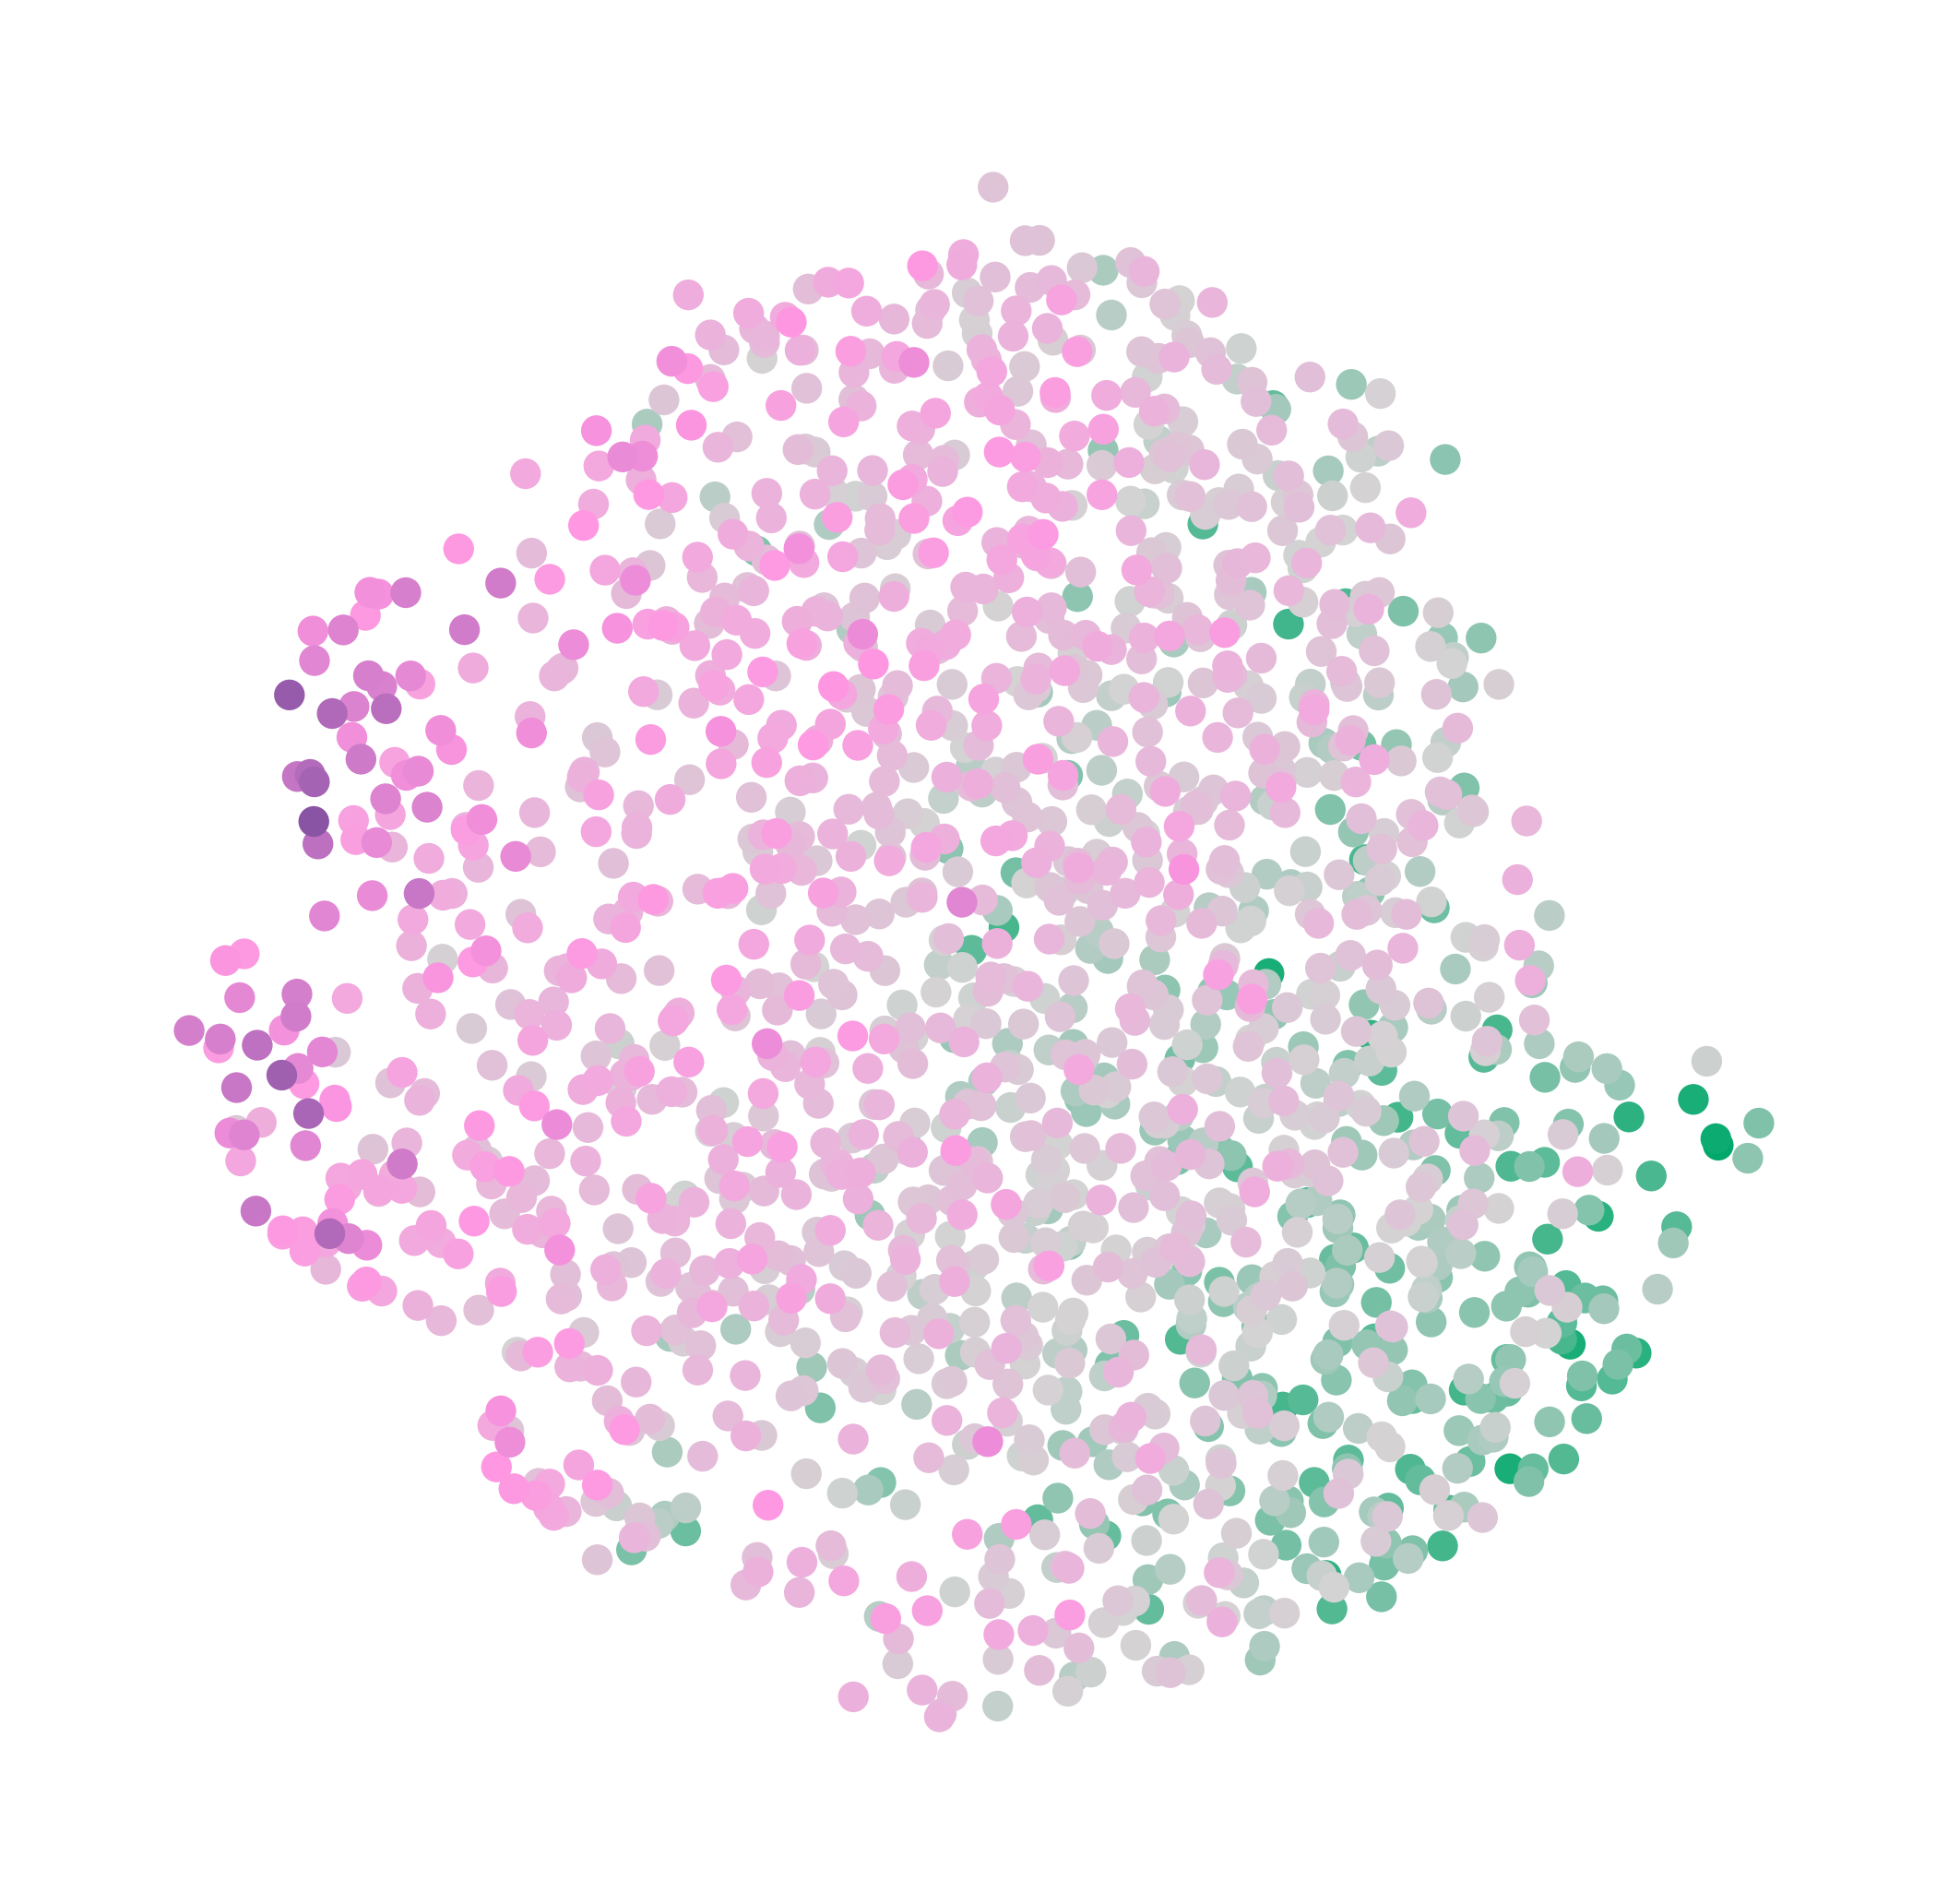

In [ ]:
plt.figure(figsize=(2,2), dpi=600)

# Scatter plot
plt.scatter(umap_coords.loc[cell_order, 'x'], umap_coords.loc[cell_order, 'y'], c=macdata.obs.loc[cell_order, 'effero_score'],
            alpha=1, s=4, edgecolors='none', cmap=r_cmap)
plt.xlabel('')
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.savefig('figures/UM_new_umaps/pHrodo_UMAP.png')
plt.show()

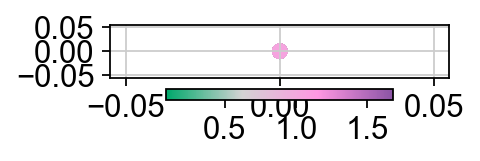

In [430]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(3, 1))

# Scatter plot with macdata.obs['effero_score'] as color values
scatter = ax.scatter([0] * len(macdata.obs['effero_score']),  # Dummy y-values
                     [0] * len(macdata.obs['effero_score']),  # Dummy x-values
                     c=macdata.obs['effero_score'],
                     cmap=r_cmap)

# Create the colorbar/legend
legend = fig.colorbar(scatter, ax=ax, orientation='horizontal')
plt.tight_layout()
plt.savefig('figures/UM_new_umaps/rodo_scale_legend_effero_score.pdf')
plt.show()


In [493]:
corr_macdata = macdata.copy()

In [494]:
sc.pp.filter_genes(corr_macdata, min_cells=10)

filtered out 24385 genes that are detected in less than 10 cells


In [495]:
#sc.pp.regress_out(corr_macdata, ['total_counts'], n_jobs=64)

In [513]:
gene_df

,pearson_r,pearson_p
FO538757.2,-0.022341,0.361131
AP006222.2,0.032705,0.181202
NOC2L,0.010409,0.670502
HES4,0.034728,0.155655
ISG15,0.054532,0.025714
...,...,...
MT-ND4,-0.126513,0.0
MT-ND5,-0.143314,0.0
MT-ND6,-0.04745,0.052323
MT-CYB,-0.180843,0.0


In [496]:
gene_df = pd.DataFrame(index=corr_macdata.var_names, columns=['pearson_r', 'pearson_p'])

In [497]:
for gene in corr_macdata.var_names:
    x = corr_macdata.obs['effero_score'].values
    y = corr_macdata[:, gene].X.todense().A1
    pearson_r, pearson_p = pearsonr(x, y)
    gene_df.loc[gene] = [pearson_r, pearson_p]

In [498]:
gene_df = gene_df[~gene_df.index.isin(new_up_and_corr_genes_human)]

In [519]:
gene_df['p_adj'] = fdrcorrection(gene_df.pearson_p.values)[1]


In [524]:
gene_df.to_excel('UM_correlations.xlsx')

In [521]:
correlated_genes = gene_df[(gene_df.p_adj < 0.05) & (gene_df.pearson_r > 0.25)].sort_values('pearson_r', ascending=False).index

In [501]:
macdata.layers['scaled'] = sc.pp.scale(macdata, copy=True, max_value=10).X

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


In [522]:
correlated_genes

Index(['CTSD', 'S100A11', 'PLA2G7', 'LIPA', 'ATP6V1F', 'SAT1', 'CD9', 'ACTB',
       'S100A10', 'SRGN', 'HLA-C', 'LAPTM5', 'SDS', 'HLA-DRB5', 'ANXA2',
       'PSAP', 'B2M', 'GRN', 'DBI', 'FCER1G', 'MMP12', 'FUCA1', 'PFN1',
       'HLA-B', 'PLD3', 'CREG1', 'CCL18', 'PLIN2', 'TXN', 'APOC1', 'CTSS',
       'TYROBP', 'IGSF6', 'GPX1', 'C1QC'],
      dtype='object')

In [503]:
for gene in correlated_genes:
    print(gene)
    plt.figure(figsize=(0.89,0.89), dpi=600)
    expr_values = macdata[:,gene].layers['scaled'].flatten()
    expr_order = np.argsort(expr_values)
    plt.scatter(umap_coords['x'][expr_order], umap_coords['y'][expr_order], alpha=1, s=0.5, edgecolors='none', c=macdata[:,gene].layers['scaled'][expr_order], cmap='bwr', vmin=-2, vmax=2)
    #plt.title(gene)
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    plt.savefig(f'figures/UM_new_umaps/{gene}_umap.png', dpi=600)
    plt.close()

CTSD
S100A11
PLA2G7
LIPA
ATP6V1F
SAT1
CD9
ACTB
S100A10
SRGN
HLA-C
LAPTM5
SDS
HLA-DRB5
ANXA2
PSAP
B2M
GRN
DBI
FCER1G
MMP12
FUCA1
PFN1
HLA-B
PLD3
CREG1
CCL18
PLIN2
TXN
APOC1
CTSS
TYROBP
IGSF6
GPX1
C1QC
NUPR1
ATP6V0C
HLA-DQA1
SH3BGRL3
PKM
MYL6
COTL1
HLA-DRB1
CTSL
RHOA
LGMN
CTSA
ASAH1
NPL
YBX1
GLUL
IFI30
LITAF
CTSH
HLA-DRA
C1QB
CD300A
NPC2
HEXB
ITM2B
TMBIM6
ADAMDEC1
AKR1B1
HLA-DPA1
FXYD5
SPI1
ARPC3
ANXA1
ATP6V0E1
LSP1
M6PR
HLA-DMA
TMEM176B
TPM4
RAC1
OAZ1
RNF130
ATP6AP2
GNG5
RNASET2
ITGB2
S100A6
SYNGR2
SLC25A5
TPI1
PPDPF
HLA-DMB
BCL2A1
GM2A
CFL1
CHIT1
ARPC2
CXCL16
CD74
HLA-A


In [504]:
old_functional_genes = ['ANXA1', 'ANXA2', 'ATP6V1F', 'CTSD', 'CTSH', 'CTSL', 'RHOA', 
                    'LIPA', 'APOC1', 'APOE',
                    'MMP12',
                    'PKM', 'PGK1', 'TPI1',
                    'CCL18', 'CXCL16', 
                    'SPI1', 'IL1RN', 'SPP1', 'TREM2', 'ADAMDEC1', 'CD300A']

In [505]:
len(old_functional_genes)

22

In [506]:
functional_genes = ["APOC1", "LIPA", "PLIN2", "DBI", "ANXA2", "S100A10", "ATP6V1F", "GRN", "CREG1", "CTSD", "CTSS", "FUCA1", "PSAP", "LAPTM5", "HLA-B", "HLA-C", "B2M", "TXN", "GPX1", "MMP12"]

In [507]:
len(functional_genes)

20

In [508]:
hm_df = macdata[:,functional_genes].to_df().iloc[np.argsort(macdata.obs.effero_score)]

In [466]:
scaled_hm_df = zscore(hm_df)

In [467]:
quantile_means = pd.DataFrame([chunk.mean() for chunk in np.array_split(scaled_hm_df, 100)]).T

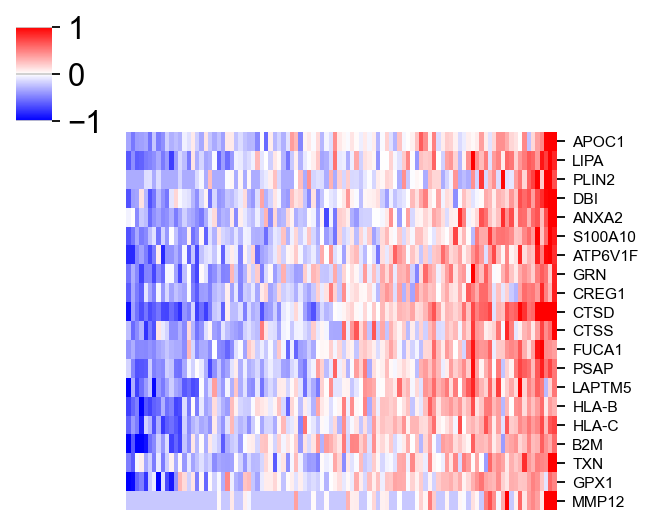

In [509]:
g = sns.clustermap(quantile_means, cmap='bwr', vmin=-1, vmax=1, center=0, col_cluster=False, row_cluster=False,
               xticklabels=False, yticklabels=True, figsize=(4.5,3.25))
g.ax_heatmap.grid(False)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='y', labelsize=7) 
plt.savefig("figures/uveal_melanoma_scaled_manual_new.pdf")


In [444]:
gene_df[~gene_df.index.isin(new_up_and_corr_genes_human)].to_csv("uveal_melanoma_effero_genes_new.csv")

 # Shared dotplot

In [445]:
ipf_genedata = pd.read_csv("correlations_IPF_both.csv", index_col=0)

In [446]:
nsclc_genedata = pd.read_csv("intmacs_nsclc_both.csv", index_col=0)

In [447]:
als_genedata = pd.read_csv("correlations_ALS_both.csv", index_col=0)

In [449]:
uveal_genedata = pd.read_csv("uveal_melanoma_effero_genes_new.csv", index_col=0)

In [450]:
uveal_genedata = uveal_genedata.dropna(subset=['pearson_p'])
als_genedata = als_genedata.dropna(subset=['pearson_p_normal', 'pearson_p_ALS'])
nsclc_genedata = nsclc_genedata.dropna(subset=['pearson_p_normal', 'pearson_p_ipf'])
ipf_genedata = ipf_genedata.dropna(subset=['pearson_p_normal', 'pearson_p_ipf'])
uveal_genedata.pearson_p = fdrcorrection(uveal_genedata.pearson_p.values)[1]
als_genedata.pearson_p_normal = fdrcorrection(als_genedata.pearson_p_normal.values)[1]
als_genedata.pearson_p_ALS = fdrcorrection(als_genedata.pearson_p_ALS.values)[1]
nsclc_genedata.pearson_p_normal = fdrcorrection(nsclc_genedata.pearson_p_normal.values)[1]
nsclc_genedata.pearson_p_ipf = fdrcorrection(nsclc_genedata.pearson_p_ipf.values)[1]
ipf_genedata.pearson_p_normal = fdrcorrection(ipf_genedata.pearson_p_normal.values)[1]
ipf_genedata.pearson_p_ipf = fdrcorrection(ipf_genedata.pearson_p_ipf.values)[1]

In [451]:
uveal_genedata.loc[functional_genes].pearson_r.min()

0.0981928972379537

In [452]:
uveal_genedata.loc[functional_genes].pearson_p.max()

0.0006951255366780102

In [454]:
# Get the union of all gene indices
all_genes = (
    set(als_genedata.index)
    | set(ipf_genedata.index)
    | set(nsclc_genedata.index)
    | set(uveal_genedata.index)
)

In [455]:
unified_pearson_df = pd.DataFrame(
    index=sorted(all_genes),
    data={
        "ALS_normal_R": als_genedata.reindex(all_genes)["pearson_r_normal"] if "pearson_r_normal" in als_genedata else als_genedata.reindex(all_genes)["pearson_r"],
        "ALS_normal_p": als_genedata.reindex(all_genes)["pearson_p_normal"] if "pearson_p_normal" in als_genedata else als_genedata.reindex(all_genes)["pearson_p"],
        "ALS_disease_R": als_genedata.reindex(all_genes)["pearson_r_ALS"] if "pearson_r_ALS" in als_genedata else als_genedata.reindex(all_genes)["pearson_r"],
        "ALS_disease_p": als_genedata.reindex(all_genes)["pearson_p_ALS"] if "pearson_p_ALS" in als_genedata else als_genedata.reindex(all_genes)["pearson_p"],
        "IPF_normal_R": ipf_genedata.reindex(all_genes)["pearson_r_normal"] if "pearson_r_normal" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_r"],
        "IPF_normal_p": ipf_genedata.reindex(all_genes)["pearson_p_normal"] if "pearson_p_normal" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_p"],
        "IPF_disease_R": ipf_genedata.reindex(all_genes)["pearson_r_ipf"] if "pearson_r_ipf" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_r"],
        "IPF_disease_p": ipf_genedata.reindex(all_genes)["pearson_p_ipf"] if "pearson_p_ipf" in ipf_genedata else ipf_genedata.reindex(all_genes)["pearson_p"],
        "NSCLC_normal_R": nsclc_genedata.reindex(all_genes)["pearson_r_normal"] if "pearson_r_normal" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_r"],
        "NSCLC_normal_p": nsclc_genedata.reindex(all_genes)["pearson_p_normal"] if "pearson_p_normal" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_p"],
        "NSCLC_disease_R": nsclc_genedata.reindex(all_genes)["pearson_r_ipf"] if "pearson_r_ipf" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_r"],
        "NSCLC_disease_p": nsclc_genedata.reindex(all_genes)["pearson_p_ipf"] if "pearson_p_ipf" in nsclc_genedata else nsclc_genedata.reindex(all_genes)["pearson_p"],
        "UM_R": uveal_genedata.reindex(all_genes)["pearson_r"],
        "UM_p": uveal_genedata.reindex(all_genes)["pearson_p"],
    }
)


In [456]:
long_df = (
    unified_pearson_df
    .reset_index()
    .melt(id_vars='index', var_name='variable', value_name='value')
)

# Split variable into model, condition, and stat (R or p)
long_df[['model', 'condition', 'stat']] = long_df['variable'].str.extract(r'^(ALS|IPF|NSCLC|UM)_?(normal|disease)?_?(R|p)?$')


In [457]:
# Fix UM rows (UM_R, UM_p have no condition)
long_df.loc[long_df['model'] == 'UM', 'condition'] = 'disease'

# Pivot so each row is a gene/model/condition, with columns R and p
long_df = long_df.pivot_table(
    index=['index', 'model', 'condition'],
    columns='stat',
    values='value'
).reset_index()

# Calculate -log10(P)
long_df['minus_log10_p'] = -np.log10(long_df['p'])

# Rename columns for clarity
long_df = long_df.rename(columns={'index': 'gene', 'R': 'R', 'p': 'P', 'model': 'model', 'condition': 'condition'})

long_df


/opt/micromamba/envs/mosko_effero_py/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


stat,gene,model,condition,R,P,minus_log10_p
0,A1BG,ALS,disease,0.067707,2.595045e-15,14.585855
1,A1BG,ALS,normal,0.066729,5.606510e-05,4.251307
2,A1BG,IPF,disease,-0.031861,3.598145e-02,1.443921
3,A1BG,IPF,normal,0.003831,8.945557e-01,0.048393
4,A1BG,NSCLC,disease,0.050015,1.077465e-01,0.967597
...,...,...,...,...,...,...
108623,ZZZ3,UM,disease,0.027730,4.642806e-01,0.333219
108624,bP-21264C1.2,IPF,disease,0.007951,6.897742e-01,0.161293
108625,bP-21264C1.2,IPF,normal,0.030696,1.275008e-01,0.894487
108626,bP-21264C1.2,NSCLC,disease,0.005675,9.067120e-01,0.042531


In [458]:
long_df.loc[long_df.minus_log10_p.values > 9, 'minus_log10_p'] = 9

In [459]:
long_df[['model', 'condition']].value_counts()

model  condition
ALS    disease      20330
       normal       20330
IPF    disease      15971
       normal       15971
NSCLC  disease      13385
       normal       13385
UM     disease       9256
Name: count, dtype: int64

In [460]:
selected_genes = ['TUBA1B',
 'LIPA',
 'CTSH',
 'TREM2',
 'APOE',
 'APOC1',
 'C1QC',
 'C1QB',
 'HLA-DRA',
 'HLA-DRB1',
 'CD74',
 'VEGFA',
 'VEGFB',
 'PDE8A',
 'HBEGF',
 'GRAMD1B',
 'DPP4',
 'ABCG1',
 'ERO1A',
 'CD58', 'ADTRP', 'CAT', 'CIR1', 'SLC27A3', #IPF
 'RXRA', 'BMP2K', 'CLEC4A', #NSCLC'
 'MMP12' # UM
]

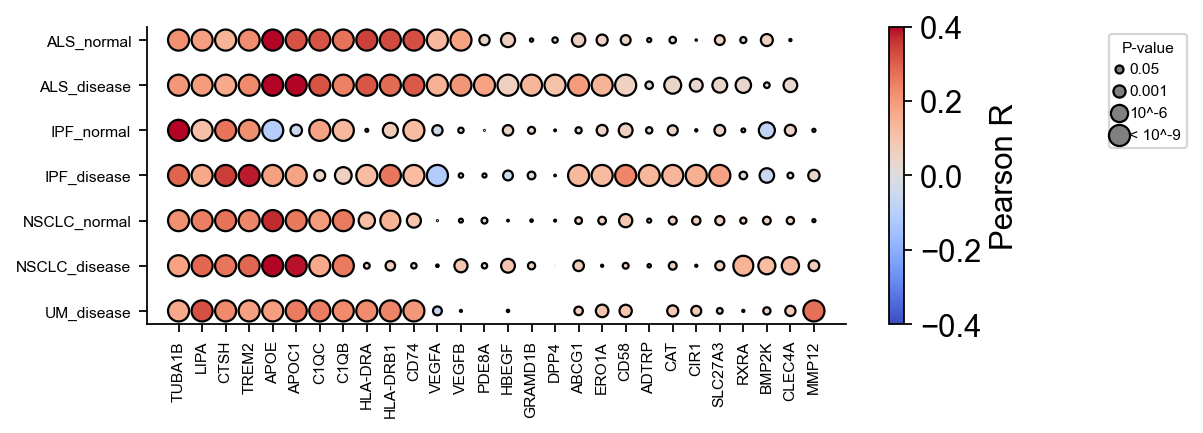

In [461]:
size_times = 10


plot_df = long_df[long_df['gene'].isin(selected_genes)].copy()

# Set categorical order for genes and models for consistent plotting
plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=selected_genes, ordered=True)
model_order = ['ALS', 'IPF', 'NSCLC', 'UM']
condition_order = ['normal', 'disease']
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df['condition'] = pd.Categorical(plot_df['condition'], categories=condition_order, ordered=True)

# Assign y positions for each (model, condition)
plot_df['y'] = plot_df['model'].astype(str) + "_" + plot_df['condition'].astype(str)
y_order = ['ALS_normal', 'ALS_disease',
           'IPF_normal', 'IPF_disease',
           'NSCLC_normal', 'NSCLC_disease', 'UM_disease']
plot_df['y'] = pd.Categorical(plot_df['y'], categories=y_order, ordered=True)

plt.figure(figsize=(len(selected_genes)*0.25, len(y_order)*0.35))
# Use categorical codes for x and y axes
x = plot_df['gene'].cat.codes
y = plot_df['y'].cat.codes

# Reverse the order of y_order and update plot_df['y'] accordingly
y_order = y_order[::-1]
plot_df['y'] = pd.Categorical(plot_df['y'], categories=y_order, ordered=True)
y = plot_df['y'].cat.codes

sc = plt.scatter(
    x=x,
    y=y,
    s=plot_df['minus_log10_p']*size_times,
    c=plot_df['R'],
    cmap='coolwarm',
    vmin=-0.4,
    vmax=0.4,
    edgecolor='k'
)

# Remove top and right axis spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(ticks=range(len(selected_genes)), labels=selected_genes, rotation=90, fontsize=7)
plt.yticks(ticks=range(len(y_order)), labels=y_order, fontsize=7)
plt.xlabel('')
plt.ylabel('')
plt.colorbar(sc, label='Pearson R')
#plt.tight_layout()
plt.grid(False)

# Add dot size legend
size_legend_p = [0.05, 1e-3, 1e-6, 1e-9]  # Example p-values for legend
size_legend = -np.log10(size_legend_p)
size_legend_labels = ["0.05", "0.001", "10^-6", "< 10^-9"]  # Corresponding labels for legend
size_legend_sizes = size_legend * size_times  
for size, label in zip(size_legend_sizes, size_legend_labels):
    plt.scatter([], [], s=size, c='gray', edgecolor='k', label=label)
plt.legend(title='P-value', loc='upper right', bbox_to_anchor=(1.5, 1), fontsize=7, title_fontsize=7)
plt.savefig("figures/per_disease_effero_correlations_new.pdf")
plt.show()


In [462]:
unified_pearson_df.to_excel("correlations_all_models_new.xlsx")